In [1]:
import sys
print(sys.executable)

D:\ecommerce-churn-platform\venv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, 
    ConfusionMatrixDisplay, precision_recall_curve, auc
)
from imblearn.over_sampling import SMOTE
import shap
import joblib
import warnings
warnings.filterwarnings("ignore")

print("All imports successful")

All imports successful


D:\ecommerce-churn-platform\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv("../data/processed/features.csv")

# Drop non-feature columns
FEATURE_COLS = [
    "Recency", "Frequency", "Monetary", "AvgOrderValue",
    "UniqueProducts", "TotalItems", "Tenure", "return_rate", "season"
] + [c for c in df.columns if c.startswith("country_")]

TARGET = "churned"

X = df[FEATURE_COLS].fillna(0)
y = df[TARGET]

print(f"Feature shape: {X.shape}")
print(f"Churn rate: {y.mean():.1%}")
print(f"Features: {list(X.columns)}")

Feature shape: (3604, 15)
Churn rate: 49.1%
Features: ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'TotalItems', 'Tenure', 'return_rate', 'season', 'country_Belgium', 'country_France', 'country_Germany', 'country_Other', 'country_Spain', 'country_United Kingdom']


In [4]:
# Scale first
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# SMOTE: handle class imbalance BEFORE splitting
# Important: fit SMOTE only on training data
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

print(f"Before SMOTE — Class 0: {(y_train_raw==0).sum()}, Class 1: {(y_train_raw==1).sum()}")
print(f"After SMOTE  — Class 0: {(y_train==0).sum()}, Class 1: {(y_train==1).sum()}")

Before SMOTE — Class 0: 1467, Class 1: 1416
After SMOTE  — Class 0: 1467, Class 1: 1467


In [5]:
# Model 1: Random Forest
rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=8, 
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Model 2: Logistic Regression
lr = LogisticRegression(
    C=0.1, 
    class_weight="balanced", 
    random_state=42, 
    max_iter=1000
)
lr.fit(X_train, y_train)

# Cross-validation scores
rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring="roc_auc")
lr_cv = cross_val_score(lr, X_train, y_train, cv=5, scoring="roc_auc")

print(f"Random Forest CV ROC-AUC: {rf_cv.mean():.3f} ± {rf_cv.std():.3f}")
print(f"Logistic Regression CV ROC-AUC: {lr_cv.mean():.3f} ± {lr_cv.std():.3f}")

Random Forest CV ROC-AUC: 0.764 ± 0.017
Logistic Regression CV ROC-AUC: 0.744 ± 0.026


In [12]:
import numpy as np
import pandas as pd

# Use your trained model + test data
probs = rf.predict_proba(X_test)[:, 1]

# Create evaluation dataframe
eval_df = pd.DataFrame({
    "y_true": y_test.values,
    "prob": probs,
    "monetary": X.loc[y_test.index, "Monetary"].values
})

print(eval_df.head())

   y_true      prob  monetary
0       1  0.802470    326.40
1       0  0.436694    831.66
2       1  0.366750    696.68
3       1  0.431686   2791.59
4       1  0.647495    416.90


In [13]:
thresholds = np.arange(0.1, 0.91, 0.01)

COST_PER_CUSTOMER = 15
SUCCESS_RATE = 0.25

results = []

for t in thresholds:
    selected = eval_df[eval_df["prob"] >= t]
    
    if len(selected) == 0:
        continue
    
    selected = selected.copy()
    selected["revenue_at_risk"] = selected["monetary"] * selected["prob"]
    
    revenue_saved = selected["revenue_at_risk"].sum() * SUCCESS_RATE
    campaign_cost = len(selected) * COST_PER_CUSTOMER
    profit = revenue_saved - campaign_cost
    
    results.append({
        "threshold": t,
        "customers": len(selected),
        "revenue_saved": revenue_saved,
        "cost": campaign_cost,
        "profit": profit
    })

results_df = pd.DataFrame(results)

print(results_df.head())

   threshold  customers  revenue_saved  cost        profit
0       0.10        646   62137.212904  9690  52447.212904
1       0.11        644   61265.776375  9660  51605.776375
2       0.12        639   59991.201335  9585  50406.201335
3       0.13        629   58961.754219  9435  49526.754219
4       0.14        629   58961.754219  9435  49526.754219


In [14]:
best = results_df.sort_values("profit", ascending=False).iloc[0]

print("Optimal Threshold:", round(best["threshold"], 2))
print("Customers to target:", int(best["customers"]))
print("Expected Profit:", int(best["profit"]))

Optimal Threshold: 0.1
Customers to target: 646
Expected Profit: 52447


In [15]:
results_df.sort_values("profit", ascending=False).head(10)

,threshold,customers,revenue_saved,cost,profit
0,0.10,646,62137.212904,9690,52447.212904
1,0.11,644,61265.776375,9660,51605.776375
2,0.12,639,59991.201335,9585,50406.201335
3,0.13,629,58961.754219,9435,49526.754219
4,0.14,629,58961.754219,9435,49526.754219
5,0.15,625,58585.154503,9375,49210.154503
6,0.16,618,57964.677406,9270,48694.677406
7,0.17,616,57740.051819,9240,48500.051819
8,0.18,615,57700.152560,9225,48475.152560
9,0.19,610,57021.960681,9150,47871.960681


=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.72      0.67      0.70       367
           1       0.68      0.73      0.71       354

    accuracy                           0.70       721
   macro avg       0.70      0.70      0.70       721
weighted avg       0.70      0.70      0.70       721

ROC-AUC: 0.7665

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0       0.71      0.66      0.68       367
           1       0.67      0.72      0.70       354

    accuracy                           0.69       721
   macro avg       0.69      0.69      0.69       721
weighted avg       0.69      0.69      0.69       721

ROC-AUC: 0.7532


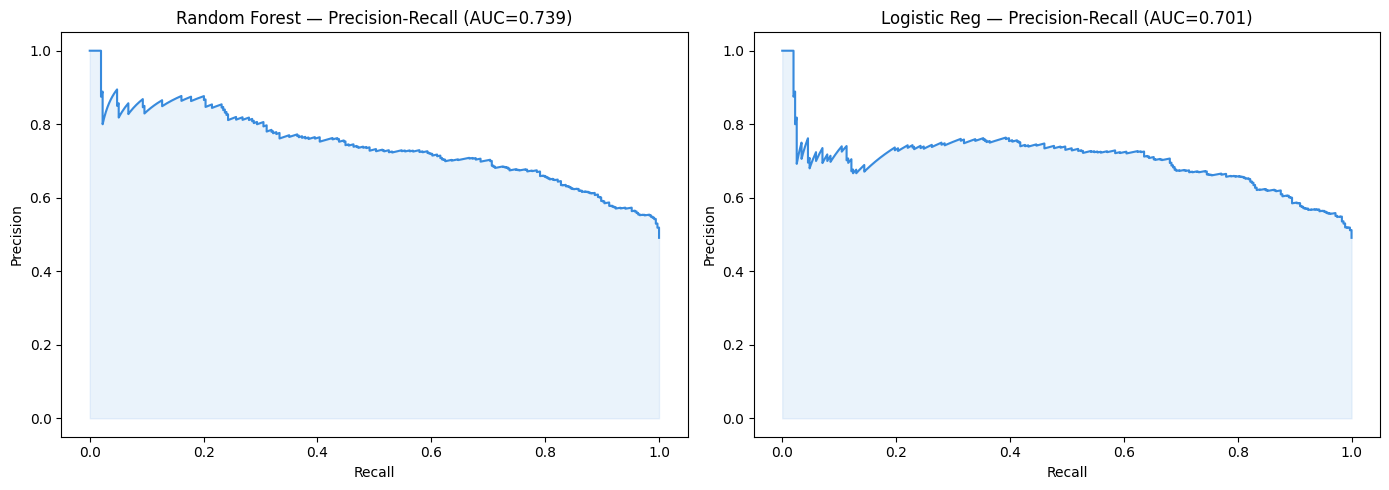

In [6]:
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST ===")
print(classification_report(y_test, rf_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_prob):.4f}")

print("\n=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, lr_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_prob):.4f}")

# Precision-Recall curve (better than ROC for imbalanced classes)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, prob, name in [(axes[0], rf_prob, "Random Forest"), (axes[1], lr_prob, "Logistic Reg")]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    pr_auc = auc(rec, prec)
    ax.plot(rec, prec, color="#378ADD")
    ax.fill_between(rec, prec, alpha=0.1, color="#378ADD")
    ax.set_title(f"{name} — Precision-Recall (AUC={pr_auc:.3f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")

plt.tight_layout()
plt.savefig("../reports/precision_recall_curves.png", dpi=150)
plt.show()

Raw SHAP shape: (200, 15, 2)
X_test shape: (200, 15)
Fixed SHAP shape: (200, 15)


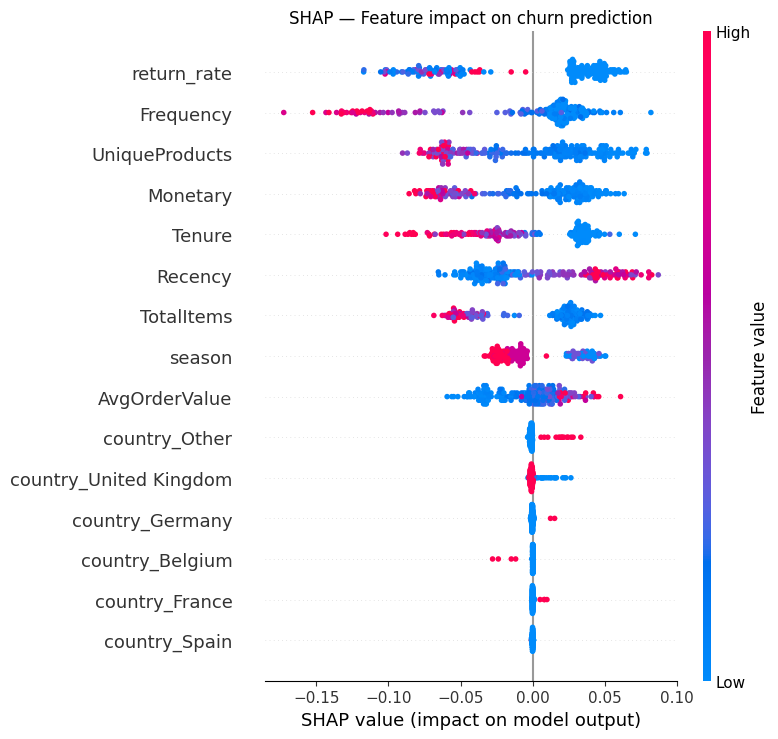

SHAP chart saved


In [7]:
explainer = shap.Explainer(rf)

# Compute SHAP values
shap_values = explainer(X_test[:200])

print("Raw SHAP shape:", shap_values.values.shape)
print("X_test shape:", X_test[:200].shape)

# Select class 1 (churn)
shap_vals = shap_values.values[:, :, 1]

print("Fixed SHAP shape:", shap_vals.shape)

# Plot
plt.figure()
shap.summary_plot(
    shap_vals,
    X_test[:200],
    feature_names=FEATURE_COLS,
    show=False
)

plt.title("SHAP — Feature impact on churn prediction")
plt.tight_layout()
plt.savefig("../reports/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

print("SHAP chart saved")

In [8]:
# Add churn probability back to the features dataframe
df["churn_probability"] = rf.predict_proba(scaler.transform(X.fillna(0)))[:, 1]
df["revenue_at_risk"] = df["Monetary"] * df["churn_probability"]
df["segment"] = df.apply(
    lambda row: (
        "Champion" if row["Recency"] <= 30 and row["Frequency"] >= 5
        else "Loyal" if row["Recency"] <= 60 and row["Frequency"] >= 3
        else "At Risk" if row["Recency"] > 120
        else "Other"
    ), axis=1
)

total_revenue_at_risk = df["revenue_at_risk"].sum()
high_risk = df[df["churn_probability"] > 0.7]

print(f"Total revenue at risk: £{total_revenue_at_risk:,.0f}")
print(f"High-risk customers (>70% probability): {len(high_risk)}")
print(f"Revenue at risk from high-risk group: £{high_risk['revenue_at_risk'].sum():,.0f}")
print(f"\nTop 10 customers to target first:")
print(
    high_risk.nlargest(10, "revenue_at_risk")[
        ["CustomerID", "Monetary", "churn_probability", "revenue_at_risk"]
    ]
)

df.to_csv("../data/processed/features_with_predictions.csv", index=False)

Total revenue at risk: £1,378,926
High-risk customers (>70% probability): 878
Revenue at risk from high-risk group: £379,354

Top 10 customers to target first:
      CustomerID  Monetary  churn_probability  revenue_at_risk
0          12346  77183.60           0.860096     66385.321513
2099       15749  44534.30           0.704761     31386.016041
1696       15098  39916.50           0.784767     31325.150921
478        13093   7832.47           0.732521      5737.452461
63         12435   7829.89           0.707874      5542.578033
3342       17850   5391.21           0.818961      4415.191520
273        12755   3811.95           0.817570      3116.536734
3583       18251   4314.72           0.713852      3080.073319
2976       17230   3638.41           0.715407      2602.943046
507        13135   3096.00           0.822504      2546.472184


In [9]:
joblib.dump(rf, "../models/random_forest_churn.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(FEATURE_COLS, "../models/feature_cols.pkl")
print("Model, scaler, and feature list saved to models/")

Model, scaler, and feature list saved to models/
